In [7]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 scikit-learn matplotlib seaborn

import torch, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

from peft import AdaLoraConfig, get_peft_model   # ✅ FIXED IMPORT

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv(
    "/content/drive/MyDrive/Emotion Dataset.csv",
    encoding="latin1",
    on_bad_lines="skip"
)[['Text','Sentiment']].dropna()

label_mapping = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4,
    "surprise": 5
}

df['label'] = df['Sentiment'].map(label_mapping)
df = df.dropna(subset=['label'])

print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"{k}: {v}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nTrain={len(train_texts)} | Val={len(val_texts)} | Test={len(test_texts)}")

Mounted at /content/drive
Label Mapping:
sadness: 0
joy: 1
love: 2
anger: 3
fear: 4
surprise: 5

Train=60000 | Val=7500 | Test=7500


In [9]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_enc   = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_enc  = tokenizer(test_texts, truncation=True, padding=True, max_length=128)


class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_ds = EmotionDataset(train_enc, train_labels)
val_ds   = EmotionDataset(val_enc, val_labels)
test_ds  = EmotionDataset(test_enc, test_labels)

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds) * 100

    prec, rec, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    return {
        "Accuracy": acc,
        "Precision": prec * 100,
        "Recall": rec * 100,
        "F1 Score": f1 * 100
    }

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

adalora_cfg = AdaLoraConfig(
    init_r=12,
    target_r=4,
    beta1=0.85,
    beta2=0.85,
    tinit=200,
    tfinal=1000,
    deltaT=10,
    lora_alpha=32,
    lora_dropout=0.1,
    task_type="SEQ_CLS",
    target_modules=["q_lin", "v_lin", "out_lin"]
)

model = get_peft_model(model, adalora_cfg)

args = TrainingArguments(
    output_dir="./emotion-distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    fp16=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

train_output = trainer.train()
metrics = trainer.evaluate(test_ds)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,0.251800,0.200192,92.386667,92.448458,92.386667,92.389303
2,0.161700,0.156971,93.026667,93.167437,93.026667,93.035530
3,0.143400,0.156480,93.520000,93.864725,93.520000,93.382912
4,0.116700,0.125686,93.786667,94.044207,93.786667,93.865158
5,0.104300,0.118467,93.840000,94.122798,93.840000,93.925119


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in ver

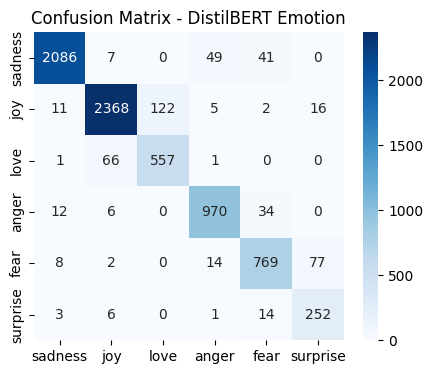

In [12]:
preds_out = trainer.predict(test_ds)

preds = np.argmax(preds_out.predictions, axis=1)

cm = confusion_matrix(test_ds.labels, preds)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_mapping.keys(),
    yticklabels=label_mapping.keys()
)

plt.title("Confusion Matrix - DistilBERT Emotion")
plt.show()

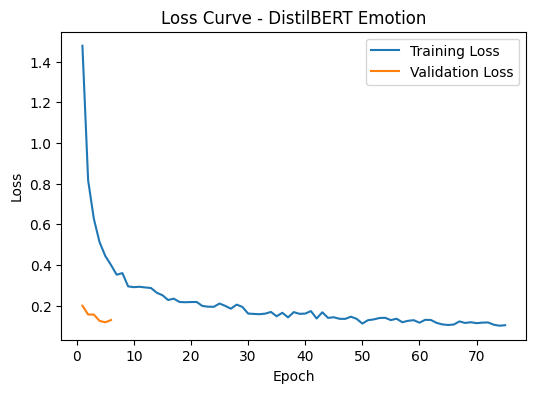

In [13]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x]
eval_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(train_loss)+1),
    train_loss,
    label="Training Loss"
)

plt.plot(
    range(1, len(eval_loss)+1),
    eval_loss,
    label="Validation Loss"
)

plt.title("Loss Curve - DistilBERT Emotion")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [14]:
probs = torch.nn.functional.softmax(
    torch.tensor(preds_out.predictions),
    dim=1
)

confidence = probs.max(dim=1).values.numpy().mean() * 100

labels_onehot = np.eye(len(label_mapping))[test_ds.labels]

similarity = cosine_similarity(
    preds_out.predictions,
    labels_onehot
).mean() * 100


results = {

    "Model": "AdaLoRA DistilBERT",

    "Accuracy": f"{metrics['eval_Accuracy']:.2f}%",
    "Precision": f"{metrics['eval_Precision']:.2f}%",
    "Recall": f"{metrics['eval_Recall']:.2f}%",
    "F1 Score": f"{metrics['eval_F1 Score']:.2f}%",

    "Similarity": f"{similarity:.2f}%",
    "Confidence": f"{confidence:.2f}%",

    "Training Time (s)": f"{train_output.metrics['train_runtime']:.4f}",

    "Trainable Params": sum(
        p.numel() for p in model.parameters() if p.requires_grad
    ),

    "GPU Memory (GB)": f"{torch.cuda.max_memory_allocated()/1024**3:.6f}"
}

df_results = pd.DataFrame([results])

print("\n==============================")
print("EMOTION MODEL RESULTS")
print("==============================")

print(df_results.to_string(index=False))


EMOTION MODEL RESULTS
             Model Accuracy Precision Recall F1 Score Similarity Confidence Training Time (s)  Trainable Params GPU Memory (GB)
AdaLoRA DistilBERT   93.36%    93.69% 93.36%   93.46%    -15.88%     95.60%         2297.4006            927198        0.493796
